In [19]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
import seaborn as sb



In [20]:
df=pd.read_csv("loan_approval_dataset.csv")
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [21]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [22]:
le=LabelEncoder()
df[' loan_status']=le.fit_transform(df[' loan_status'])
df[" education"]=le.fit_transform(df[' education'])
df[' self_employed']=le.fit_transform(df[' self_employed'])


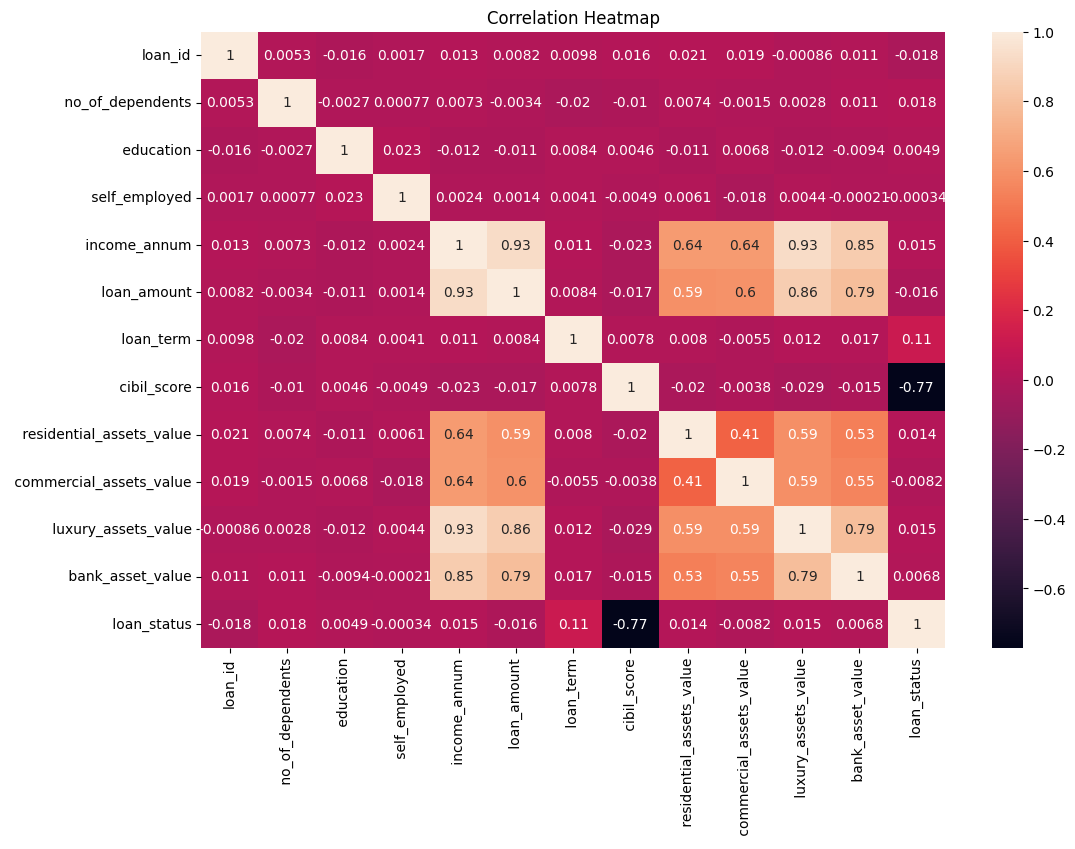

In [ ]:
plt.figure(figsize=(12,8))
sb.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
y=df[' loan_status']
x=df.drop(columns=[' loan_status'])




In [24]:
sc=StandardScaler()
x=sc.fit_transform(x)


In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [27]:
prediction=model.predict(x_test)
accuracy=accuracy_score(y_test,prediction)
print(f"Testing accuracy is {accuracy*100}")

Testing accuracy is 90.74941451990632


In [28]:
cr=classification_report(y_test,prediction)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854



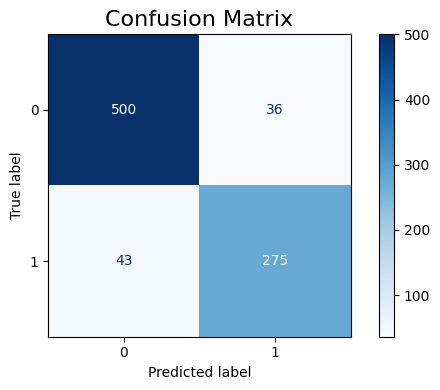

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax=plt.subplots(figsize=(6,4))
disp=ConfusionMatrixDisplay.from_predictions(   
    y_test,
    prediction,
    ax=ax,
    cmap="Blues"
)
disp.ax_.set_title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()